# Mental Health Text Analysis using Word2Vec and FastText

## Introduction
In this project, we perform an end-to-end Natural Language Processing (NLP) analysis on mental health text data. The objective is to understand semantic relationships between words and also build a prediction system.

We use Word2Vec and FastText models to convert text into numerical vectors and analyze similarities between mental health terms. Additionally, we build a simple prediction model and deploy it using Streamlit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim.models import Word2Vec, FastText
from sklearn.decomposition import PCA

from collections import Counter
from wordcloud import WordCloud

In [2]:
df = pd.read_csv(r"C:\Users\srira\Downloads\archive\Mental_health.csv")
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [4]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197204 entries, 0 to 197203
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   statement  197134 non-null  object
 1   status     197204 non-null  object
dtypes: object(2)
memory usage: 3.0+ MB


In [6]:
df.isnull().sum()

statement    70
status        0
dtype: int64

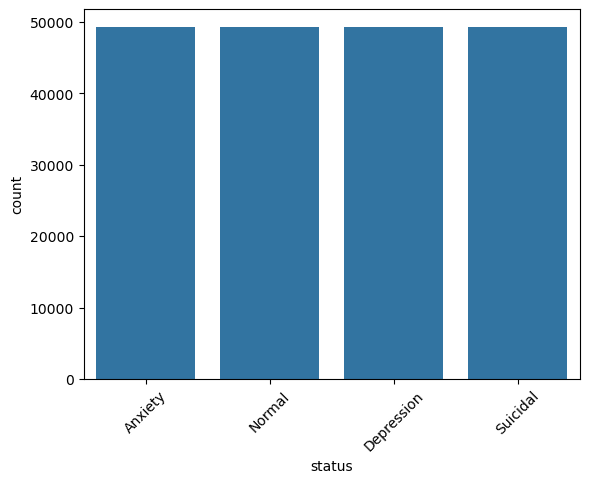

In [7]:
sns.countplot(x='status', data=df)
plt.xticks(rotation=45)
plt.show()

## Data Cleaning

In [8]:
df = df.dropna(subset=['statement'])
df = df[df['statement'].str.strip() != ""]
df.reset_index(drop=True, inplace=True)

In [9]:
df.isnull().sum()

statement    0
status       0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197133 entries, 0 to 197132
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   statement  197133 non-null  object
 1   status     197133 non-null  object
dtypes: object(2)
memory usage: 3.0+ MB


## Text Preprocessing

In [11]:
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = word_tokenize(text)
    return [w for w in tokens if w not in stop_words]

df['tokens'] = df['statement'].apply(clean_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\srira\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\srira\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## words frequency analysis

In [12]:
all_words = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_words)

common_words = word_freq.most_common(10)
common_words

[('like', 148897),
 ('feel', 114564),
 ('know', 89195),
 ('get', 88984),
 ('want', 84985),
 ('anxiety', 81759),
 ('life', 69959),
 ('time', 69080),
 ('really', 66713),
 ('even', 64320)]

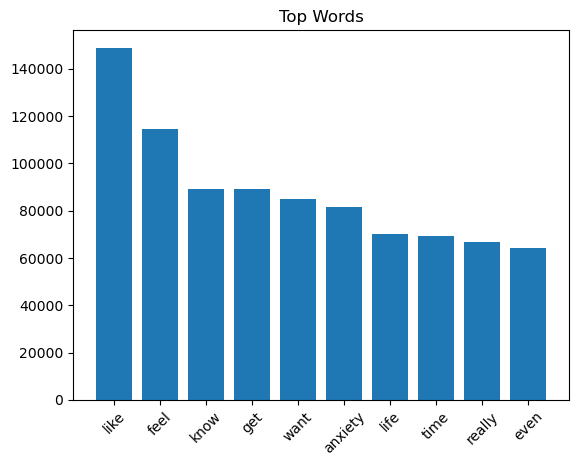

In [13]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words")
plt.show()

## word2vec model

In [16]:
w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [17]:
w2v_model.wv.similarity('stress', 'anxiety')

np.float32(0.5505038)

In [18]:
w2v_model.wv.most_similar('depression')

[('ocd', 0.6811471581459045),
 ('bpd', 0.6808171272277832),
 ('gad', 0.6362848281860352),
 ('ptsd', 0.6299086809158325),
 ('adhd', 0.6224519610404968),
 ('dysthymia', 0.5849084258079529),
 ('depressive', 0.5838428735733032),
 ('mdd', 0.577305793762207),
 ('agoraphobia', 0.5764416456222534),
 ('separation', 0.5713767409324646)]

In [19]:
w2v_model.wv.similarity('depression','sad')

np.float32(0.19777735)

In [20]:
w2v_model.wv.similarity('happy','calm')

np.float32(0.23018542)

In [21]:
w2v_model.wv.similarity('panic','fear')

np.float32(0.25332278)

In [22]:
w2v_model.wv.doesnt_match(['happy', 'sad', 'depressed', 'table'])

'table'

In [23]:
w2v_model.wv.similarity('happy','depression')

np.float32(0.21647573)

In [24]:
w2v_model.wv.similarity('calm','panic')

np.float32(0.29648665)

In [25]:
w2v_model.wv['anxiety']

array([ 1.8621782 , -1.6757196 , -0.07612263,  0.41655323, -4.3189754 ,
        2.0025444 ,  1.8951783 , -5.46145   ,  0.08868859, -1.6581565 ,
       -0.33466116,  1.871562  ,  1.3692727 , -1.269603  , -1.2055308 ,
       -0.45294115,  0.5035825 ,  1.0286163 , -1.2334938 ,  0.66417015,
       -1.6839198 ,  1.7101951 ,  0.31463492, -2.8476136 ,  2.9738195 ,
        0.0267163 ,  0.5279918 , -0.10215709,  0.8956003 ,  0.8600431 ,
       -2.474916  ,  1.1123903 ,  0.6290882 , -0.27734688,  1.4570946 ,
       -1.4572275 , -0.5726907 ,  0.24296303,  0.09521515, -0.12881452,
        4.2039714 , -1.286088  ,  0.6604647 ,  0.850664  ,  0.32469478,
        3.2100613 , -1.5066394 , -0.6558342 ,  1.3679869 , -0.18423513,
       -0.2655832 , -1.4334689 , -0.04536283,  0.5405215 ,  1.5381262 ,
        1.5383736 ,  2.9368231 ,  2.1003933 ,  0.8535544 ,  1.4379585 ,
        0.844982  , -0.03255352,  2.149584  ,  0.07787519,  0.242395  ,
       -0.63761145,  0.02289406, -2.4644618 ,  1.1088926 ,  1.07

## fasttext model

In [26]:
ft_model = FastText(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


## FASTTEXT ANALYSIS

In [27]:
ft_model.wv.similarity('stress', 'anxiety')

np.float32(0.63181376)

In [28]:
ft_model.wv.similarity('depression','sad')

np.float32(0.23390803)

In [29]:
ft_model.wv.similarity('happy','depression')

np.float32(0.2943825)

In [30]:
ft_model.wv.similar_by_word('happy')

[('happyi', 0.9788158535957336),
 ('happywe', 0.9777948260307312),
 ('happymy', 0.9641611576080322),
 ('happyahma', 0.9544896483421326),
 ('happyor', 0.9457409977912903),
 ('happyandi', 0.914279580116272),
 ('happyish', 0.9104939103126526),
 ('actvhappy', 0.9045523405075073),
 ('chappy', 0.8865547776222229),
 ('happywhen', 0.8864824771881104)]

In [31]:
ft_model.wv.most_similar('depression')

[('depressioni', 0.9783955216407776),
 ('depressionit', 0.9769594669342041),
 ('depressionwhy', 0.9734546542167664),
 ('depressionen', 0.9679892063140869),
 ('depressione', 0.9553769826889038),
 ('depressioner', 0.9549162983894348),
 ('healingfromdepression', 0.9296397566795349),
 ('depressions', 0.9278178215026855),
 ('anxietydepression', 0.9266157746315002),
 ('depressional', 0.9235296845436096)]

In [32]:
ft_model.wv.n_similarity(['stress','anxiety'], ['panic','fear'])

np.float32(0.6039063)

## Rare word handling

In [33]:
ft_model.wv.most_similar('hopelessness')

[('hopelesness', 0.9801819324493408),
 ('hoplessness', 0.937795102596283),
 ('helplessness', 0.9310206174850464),
 ('ruthlessness', 0.8826461434364319),
 ('powerlessness', 0.879645586013794),
 ('senselessness', 0.8789052963256836),
 ('lifelessness', 0.8785485625267029),
 ('aimlessness', 0.878051221370697),
 ('uselessness', 0.875150740146637),
 ('worthlessness', 0.8744616508483887)]

## comparing same word in both models

In [34]:
print("Word2Vec:", w2v_model.wv.most_similar('stress'))
print("FastText:", ft_model.wv.most_similar('stress'))

Word2Vec: [('stresses', 0.6726109385490417), ('pressure', 0.6239234805107117), ('tension', 0.5768150091171265), ('strain', 0.5676155686378479), ('workload', 0.5568944215774536), ('anxiety', 0.5505038499832153), ('distress', 0.542666494846344), ('procrastination', 0.5072189569473267), ('causing', 0.5050815343856812), ('responsibilities', 0.4774697721004486)]
FastText: [('stresss', 0.9727820158004761), ('stressy', 0.9390234351158142), ('hownostress', 0.9273785352706909), ('stresse', 0.9182372093200684), ('stressin', 0.911506712436676), ('distress', 0.8942490220069885), ('stressball', 0.8922237753868103), ('mistress', 0.885059654712677), ('stresser', 0.871579110622406), ('stressor', 0.8706406354904175)]


## testing unseen word

In [35]:
try:
    print(w2v_model.wv.most_similar('overthinkinggg'))
except:
    print("Word2Vec cannot handle unseen word")

ft_model.wv.most_similar('overthinkinggg')

Word2Vec cannot handle unseen word


[('overthinking', 0.9734684824943542),
 ('overthink', 0.9333856701850891),
 ('overthinker', 0.8960309028625488),
 ('overthiking', 0.8779953122138977),
 ('overthinked', 0.8702677488327026),
 ('overthinkers', 0.844416081905365),
 ('overanalyzing', 0.832114577293396),
 ('overthinks', 0.8302084803581238),
 ('overthetop', 0.8296902179718018),
 ('thinkingnof', 0.8264945149421692)]

## PCA VISUALIZATION

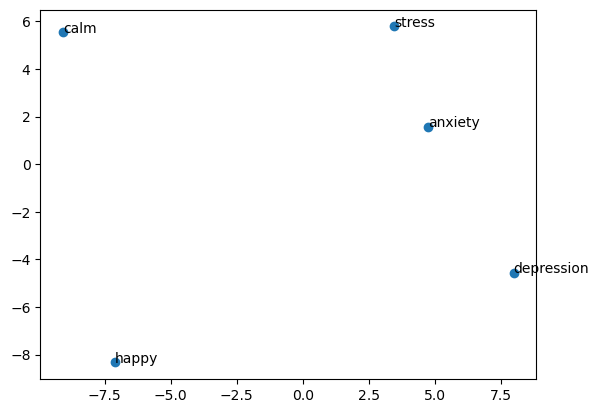

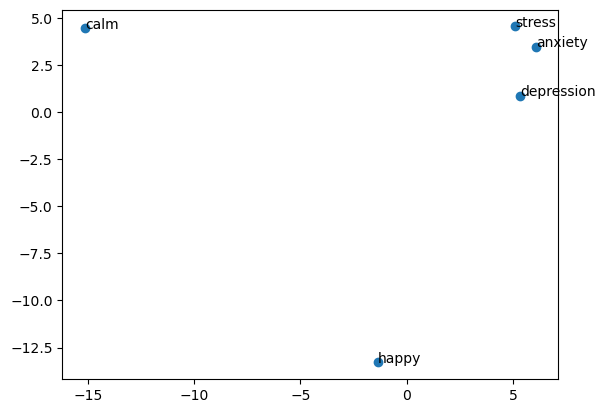

In [36]:
def plot_pca(model, words):
    vectors = [model.wv[w] for w in words if w in model.wv]
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)
    plt.scatter(result[:,0], result[:,1])
    for i, w in enumerate(words):
        if w in model.wv:
            plt.annotate(w,(result[i,0], result[i,1]))
    plt.show()

words = ['stress','anxiety','depression','happy','calm']
plot_pca(w2v_model, words)
plot_pca(ft_model, words)

## CONVERT TEXT → VECTORS

In [37]:
def sentence_vector(tokens, model):
    vec = np.zeros(model.vector_size)
    count = 0
    
    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
            
    return vec / count if count != 0 else vec

## Word2Vec Features

In [38]:
X_w2v = np.array([sentence_vector(t, w2v_model) for t in df['tokens']])

## FastText Features

In [39]:
X_ft = np.array([sentence_vector(t, ft_model) for t in df['tokens']])

## ENCODE TARGET

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [42]:
le = LabelEncoder()
y = le.fit_transform(df['status'])

## TRAIN-TEST SPLIT

In [43]:
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

X_train_ft, X_test_ft, _, _ = train_test_split(X_ft, y, test_size=0.2, random_state=42)

## BUILD MULTIPLE MODELS

## logistic regression

In [44]:
lr_w2v = LogisticRegression(max_iter=200)
lr_w2v.fit(X_train_w2v, y_train)
pred_lr_w2v = lr_w2v.predict(X_test_w2v)

## Random Forest

In [45]:
rf_w2v = RandomForestClassifier()
rf_w2v.fit(X_train_w2v, y_train)
pred_rf_w2v = rf_w2v.predict(X_test_w2v)

## Naive Bayes

In [46]:
nb_w2v = GaussianNB()
nb_w2v.fit(X_train_w2v, y_train)
pred_nb_w2v = nb_w2v.predict(X_test_w2v)

## EVALUATE MODELS

In [47]:
print("LR:", accuracy_score(y_test, pred_lr_w2v))
print("RF:", accuracy_score(y_test, pred_rf_w2v))
print("NB:", accuracy_score(y_test, pred_nb_w2v))

LR: 0.6432647677987167
RF: 0.7601389910467446
NB: 0.5507393410606944


## REPEAT FOR FASTTEXT

In [49]:
lr_ft = LogisticRegression(max_iter=200)
lr_ft.fit(X_train_ft, y_train)
pred_lr_ft = lr_ft.predict(X_test_ft)

C:\Users\srira\anaconda3\envs\base_py310_clean\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
rf_ft = RandomForestClassifier()
rf_ft.fit(X_train_ft, y_train)
pred_rf_ft = rf_ft.predict(X_test_ft)

In [51]:
nb_ft = GaussianNB()
nb_ft.fit(X_train_ft, y_train)
pred_nb_ft = nb_ft.predict(X_test_ft)

## COMPARE ALL MODELS

In [52]:
results = {
    "LR_W2V": accuracy_score(y_test, pred_lr_w2v),
    "RF_W2V": accuracy_score(y_test, pred_rf_w2v),
    "NB_W2V": accuracy_score(y_test, pred_nb_w2v),
    "LR_FT": accuracy_score(y_test, pred_lr_ft),
    "RF_FT": accuracy_score(y_test, pred_rf_ft),
    "NB_FT": accuracy_score(y_test, pred_nb_ft)
}

results

{'LR_W2V': 0.6432647677987167,
 'RF_W2V': 0.7601389910467446,
 'NB_W2V': 0.5507393410606944,
 'LR_FT': 0.6302787429933802,
 'RF_FT': 0.7518198189058259,
 'NB_FT': 0.5103355568519036}

## FIND BEST MODEL

In [53]:
best_model = max(results, key=results.get)
best_model, results[best_model]

('RF_W2V', 0.7601389910467446)

## FINAL PREDICTION

In [62]:
text = "I feel happy and relaxed"
tokens = clean_text(text)
vec = sentence_vector(tokens, ft_model).reshape(1,-1)

prediction = rf_w2v.predict(vec)
le.inverse_transform(prediction)

array(['Normal'], dtype=object)

In [55]:
rf_final = RandomForestClassifier()
rf_final.fit(X_w2v, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
from joblib import dump

dump(rf_final, "model.joblib")
dump(le, "label_encoder.joblib")

w2v_model.save("w2v.model")

In [59]:
df['status'].value_counts()

status
Depression    49301
Normal        49291
Suicidal      49287
Anxiety       49254
Name: count, dtype: int64